---
# **RED NEURONAL CONVOLUCIONAL (MODELO DEEP LEARNING)**
---
> Diagnóstico de Covid19 mediante Red Neuronal Convolucionar  en imágenes RX de Tórax *

> *Dataset*:    https://github.com/ieee8023/covid-chestxray-dataset.git 
                https://data.mendeley.com/datasets/rscbjbr9sj/2

---



 ## **INICIO**
---

**Actualizado a TensorFlow 2.X:**

In [1]:
# TensorFlow
import tensorflow as tf
print('Tensorflow: ',tf.__version__)

import keras
print('TF Keras: ',keras.__version__)

# Python
import platform
print('Python:',platform.python_version())

ModuleNotFoundError: No module named 'tensorflow'

**Visualizando imágenes del dataset:**

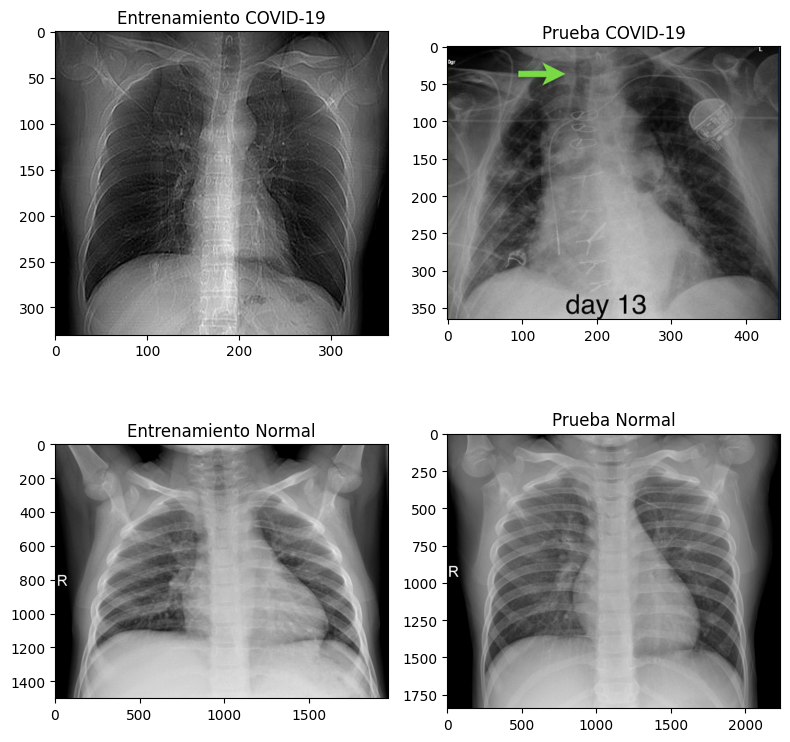

In [3]:
import os
import glob
import numpy as np
from random import choice
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Ruta de la carpeta del proyecto
project_folder = "/Software Projects/Python Projects/Deep Learning/covid19-rx-project"

# Construyendo las rutas para cada conjunto de datos
dataset_paths = {
    'train_covid19': f"{project_folder}/dataset/train/covid19/*.jpg",
    'test_covid19': f"{project_folder}/dataset/test/covid19/*.jpg",
    'train_normal': f"{project_folder}/dataset/train/normal/*.jpg",
    'test_normal': f"{project_folder}/dataset/test/normal/*.jpg"
}

# Cargando archivos de imagen al azar de cada conjunto de datos
images = {}
for key, path in dataset_paths.items():
    files = glob.glob(path)
    selected_file = choice(files)
    images[key] = image.load_img(selected_file)

# Configuración de la visualización de las imágenes
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.ravel()

titles = {
    'train_covid19': 'Entrenamiento COVID-19',
    'test_covid19': 'Prueba COVID-19',
    'train_normal': 'Entrenamiento Normal',
    'test_normal': 'Prueba Normal'
}

for ax, (key, img) in zip(axes, images.items()):
    ax.imshow(img)
    # Obtiene el nombre del archivo para el título desde la ruta del archivo seleccionado
    file_name = os.path.basename(dataset_paths[key])
    ax.set_title(titles[key])

plt.tight_layout()
plt.show()



 ## **SECCIÓN I - PREPROCESAMIENTO DE DATOS**
---

**Cargar dataset TRAIN y aplicar Data Augmentation:**

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dimensión de las imgs a procesar
img_width = 224
img_height = 224
batch_size = 40

# Data Augmentation and Normalization
datagen_train = ImageDataGenerator(rescale=1.0/255.0,      # Normalizar los valores al rango [0-1]
                                   horizontal_flip=True,   # Giro horizontal
                                   rotation_range=15,      # Giro aleatorio (clockwise) entre 0 y 15 grados
                                   width_shift_range=0.15,  # Mover la img horizontelmente 15%
                                   height_shift_range=0.15, # Mover la img verticalmente 15%
                                   zoom_range=0.2)          # Zoom in / Zoom out aleatorio de 20% => 80% - 120%

# Leer imagenes del folder dataset/train
training_set_imgs = datagen_train.flow_from_directory(project_folder+"/dataset/train",
                                                      target_size = (img_width, img_height),
                                                      class_mode = 'binary',
                                                      classes = ['normal','covid19'], #Nombre de las carpetas dentro de train
                                                      batch_size = batch_size) #Elegir 40 imágenes aleatorias
# Mostrando resultados
num_imgs_training = len(training_set_imgs.filenames)

print("\n")
print("Núm. de imgs ENTRENAMIENTO:", num_imgs_training)
print("Classes:", training_set_imgs.class_indices)
print("Núm. Classes [0]:", np.sum(training_set_imgs.labels == 0, axis=0))
print("Núm. Classes [1]:", np.sum(training_set_imgs.labels == 1, axis=0))

Found 352 images belonging to 2 classes.


Núm. de imgs ENTRENAMIENTO: 352
Classes: {'normal': 0, 'covid19': 1}
Núm. Classes [0]: 176
Núm. Classes [1]: 176


**Mostrando datos resultado de Data augmentation:**

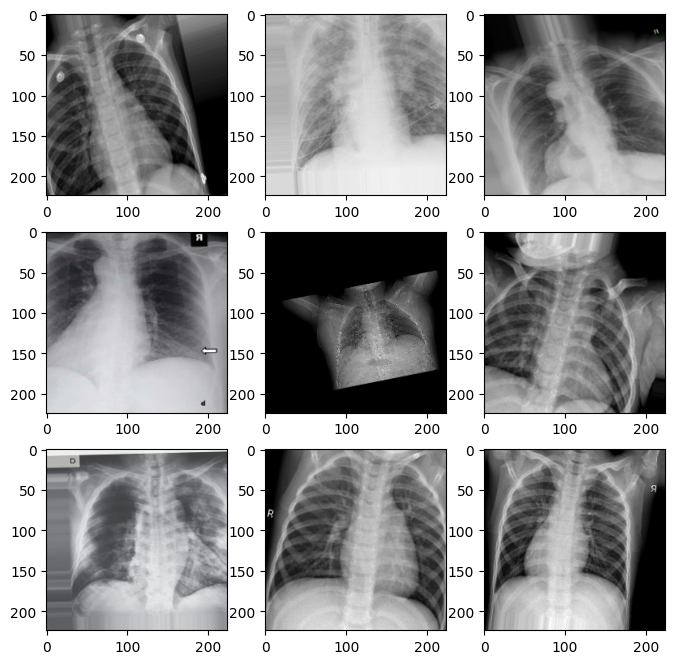

In [5]:
import copy

# Visualizando data augmentation para 1 imagen
fig = plt.gcf()
fig.set_size_inches(8, 8)

it = copy.copy(training_set_imgs)

for i in range(9):
	plt.subplot(3,3,1 + i)
	batch = it.next()[0]
	imagenp = (batch[0]*255).astype('uint8')
	plt.imshow(imagenp)
plt.show()

**Cargar dataset TEST sin aplicar Data Augmentation:**

In [6]:
# Data Normalization
datagen_test = ImageDataGenerator(rescale=1.0/255.0)

# Leer imagenes del folder dataset/train
testing_set_imgs = datagen_test.flow_from_directory(project_folder+"/dataset/test",
                                                      target_size = (img_width, img_height),
                                                      class_mode = 'binary',
                                                      classes = ['normal','covid19'],
                                                      batch_size = batch_size,
                                                      shuffle=False)
# Mostrando resultados
num_imgs_testing = len(testing_set_imgs.filenames)

print("\n")
print("Núm. de imgs TEST:", num_imgs_testing)
print("Classes:", testing_set_imgs.class_indices)
print("Núm. Classes [0]:", np.sum(testing_set_imgs.labels == 0, axis=0))
print("Núm. Classes [1]:", np.sum(testing_set_imgs.labels == 1, axis=0))

Found 88 images belonging to 2 classes.


Núm. de imgs TEST: 88
Classes: {'normal': 0, 'covid19': 1}
Núm. Classes [0]: 44
Núm. Classes [1]: 44


## **SECCIÓN II - CONSTRUYENDO LA RED NEURONAL ARTIFICIAL (CNN) - ARQUITECTURA**
---

**Cargar Modelo pre-entrenado DenseNet:**

In [7]:
# DenseNet https://keras.io/api/applications/densenet/
# https://towardsdatascience.com/paper-review-densenet-densely-connected-convolutional-networks-acf9065dfefb
from tensorflow.keras.applications.densenet import DenseNet201
# ResNet https://keras.io/api/applications/resnet/
# from keras.applications import ResNet152V2

# Cargando modelo DenseNet
pretrained_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

pretrained_model.summary();

Model: "densenet201"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 230, 230, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 112, 112, 64)         9408      ['zero_padding2d[0][0]']      
                                                                                                  
 conv1/bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1/conv[0][0]']

<!-- **Congelar (freeze) los params en el Feature Extractor:** -->

In [8]:
for layer in pretrained_model.layers:
    layer.trainable = False

pretrained_model.summary()

Model: "densenet201"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 230, 230, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 112, 112, 64)         9408      ['zero_padding2d[0][0]']      
                                                                                                  
 conv1/bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1/conv[0][0]']

**Agregando el clasificador propio:**

In [9]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import GlobalAveragePooling2D
from keras.layers import Flatten
from keras.layers import Dropout

# Definiendo una Red Neuronal vacía
model = Sequential()

# Agregando la parte convolucional (base)
model.add(pretrained_model)               # Modelo base

# Clasificador propio
model.add(GlobalAveragePooling2D())       # GlobalAveragePooling2D https://adventuresinmachinelearning.com/global-average-pooling-convolutional-neural-networks/
model.add(Dense(1000, activation='relu'))
model.add(Dropout(rate=0.2)) #Prevenir el overfitting
model.add(Dense(1, activation='sigmoid'))

print("Arquitectura final:")
model.summary()

Arquitectura final:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet201 (Functional)    (None, 7, 7, 1920)        18321984  
                                                                 
 global_average_pooling2d (  (None, 1920)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 1000)              1921000   
                                                                 
 dropout (Dropout)           (None, 1000)              0         
                                                                 
 dense_1 (Dense)             (None, 1)                 1001      
                                                                 
Total params: 20243985 (77.22 MB)
Trainable params: 1922001 (7.33 MB)
Non-trainable params: 18321984 (

2.0.0
0.20.1


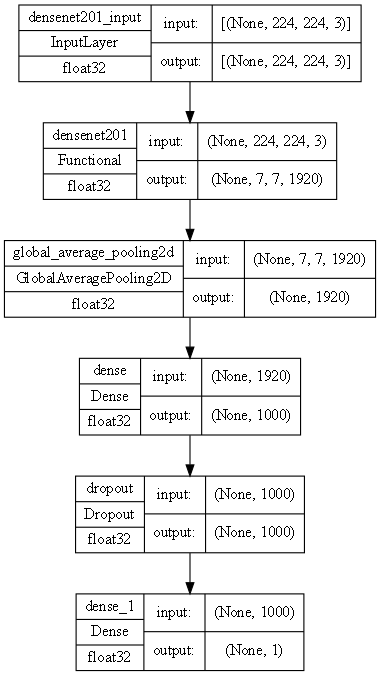

In [10]:
from tensorflow.keras.utils import plot_model
import pydot
print(pydot.__version__)
import graphviz
print(graphviz.__version__)
plot_model(model, show_dtype=True, show_shapes=True, show_layer_names=True, rankdir='TB',to_file=project_folder + '/output/model_plot.png',dpi=80)

## **SECCIÓN III - ENTRENANDO LA RED NEURONAL ARTIFICIAL (CNN)**
---

**Compilar la Red Neuronal Convolucional:**

In [11]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.optimizers import Adam

opt = SGD(learning_rate=0.008, momentum=0.9)
# opt = Adam(lr=0.008, beta_1=0.9, beta_2=0.999)

# COMPILANDO la Red Neuronal Convolucional
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

**Entrenar la Red Neuronal convolucional:**

In [12]:
%%time

epochs=20

# Entrenar
history = model.fit(training_set_imgs,
                    epochs=epochs,
                    steps_per_epoch=np.ceil(num_imgs_training/batch_size),
                    validation_data=testing_set_imgs,
                    validation_steps=np.ceil(num_imgs_testing/batch_size))

Epoch 1/20
9/9 [==============================] - 26s 3s/step - loss: 0.0832 - accuracy: 0.9602 - val_loss: 0.0359 - val_accuracy: 0.9886
Epoch 5/20
9/9 [==============================] - 26s 3s/step - loss: 0.0585 - accuracy: 0.9801 - val_loss: 0.0276 - val_accuracy: 0.9773
Epoch 6/20
9/9 [==============================] - 26s 3s/step - loss: 0.0624 - accuracy: 0.9716 - val_loss: 0.0285 - val_accuracy: 0.9886
Epoch 7/20
9/9 [==============================] - 25s 3s/step - loss: 0.0530 - accuracy: 0.9801 - val_loss: 0.0303 - val_accuracy: 0.9886
Epoch 8/20
9/9 [==============================] - 25s 3s/step - loss: 0.0744 - accuracy: 0.9773 - val_loss: 0.0286 - val_accuracy: 0.9886
Epoch 9/20
9/9 [==============================] - 25s 3s/step - loss: 0.0709 - accuracy: 0.9688 - val_loss: 0.0252 - val_accuracy: 0.9773
Epoch 10/20
9/9 [==============================] - 25s 3s/step - loss: 0.0452 - accuracy: 0.9801 - val_loss: 0.0241 - val_accuracy: 0.9886
Epoch 11/20
9/9 [================

**Graficar resultados del entrenamiento:**

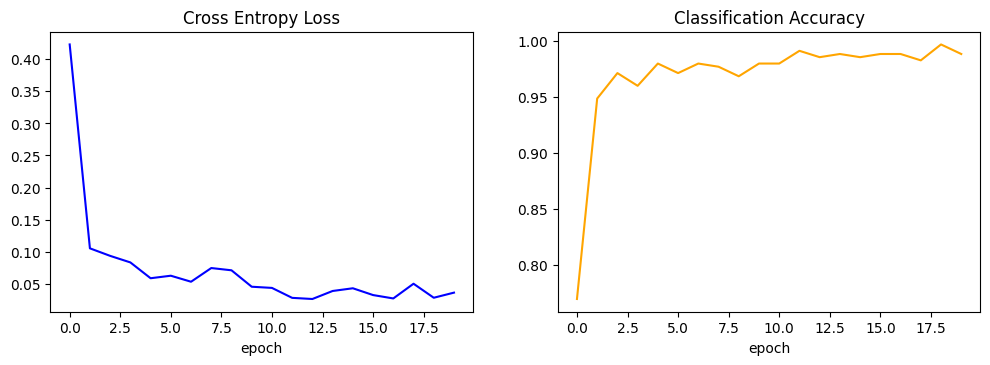

In [13]:
# GRAFICANDO resultados
import matplotlib.pyplot as plt
fig = plt.gcf()
fig.set_size_inches(12, 8)

# plot loss
plt.subplot(2,2,1)
plt.title('Cross Entropy Loss')
plt.xlabel("epoch")
plt.plot(history.history['loss'], color='blue', label='train')

# plot accuracy
plt.subplot(2,2,2)
plt.title('Classification Accuracy')
plt.xlabel("epoch")
plt.plot(history.history['accuracy'], color='orange', label='train')

## **SECCIÓN IV - EVALUACIÓN DE LA RED NEURONAL ARTIFICIAL (CNN)**
---

**Evaluación vía 'evaluate_generator':**

In [14]:
# Accuraccy del Test (Usar este valor como referencial solamente https://github.com/keras-team/keras/issues/6499)
eval = model.evaluate(testing_set_imgs, steps=np.ceil(num_imgs_testing/batch_size))

print('\nValidación en Test:')
print("Loss: {:.4}".format(eval[0]))
print("Accuracy: {:.2%}".format(eval[1]))

3/3 [==============================] - 5s 1s/step - loss: 0.0247 - accuracy: 0.9773

Validación en Test:
Loss: 0.02466
Accuracy: 97.73%


**Evaluación vía 'predict' y Matriz de Confusión:**

In [15]:
# Matriz de Confusión
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

THRESHOLD=0.5
testing_set_imgs.reset() #batch_index=0

Y_pred = model.predict(testing_set_imgs, steps=np.ceil(num_imgs_testing/batch_size))
y_pred = np.where(Y_pred >= THRESHOLD, 1, 0)
# print(Y_pred)
# print(y_pred)

cm = confusion_matrix(testing_set_imgs.classes, y_pred)
print("\nMatriz de Confusión:\n")
print(cm)

# print('\nClassification Report:')
# classes_names = ['normal', 'covid19']
# print(classification_report(testing_set_imgs.classes, y_pred, target_names=classes_names))

3/3 [==============================] - 8s 1s/step

Matriz de Confusión:

[[43  1]
 [ 1 43]]


**Visualizando la Matriz de Confusión:**

Matriz de Confusión sin Normalizar


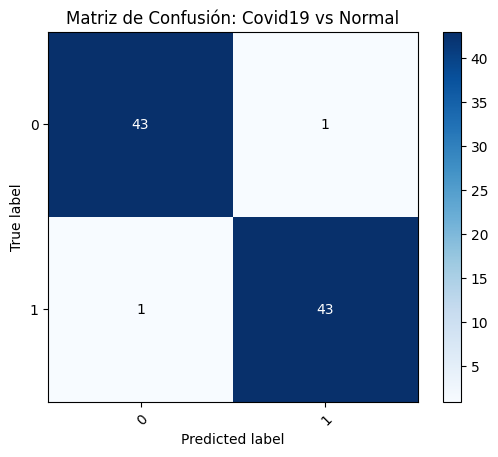

<Axes: title={'center': 'Matriz de Confusión: Covid19 vs Normal'}, xlabel='Predicted label', ylabel='True label'>

In [16]:
from sklearn.utils.multiclass import unique_labels
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred,
                          normalize=False,
                          title=None):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Matriz de Confusión Normalizada'
        else:
            title = 'Matriz de Confusión sin Normalizar'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
    classes = unique_labels(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Matriz de Confusión Normalizada")
    else:
        print('Matriz de Confusión sin Normalizar')

    # print(cm)

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.grid(linewidth=.0)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    #fig.tight_layout()
    plt.show()
    return ax


plot_confusion_matrix(testing_set_imgs.classes, y_pred, normalize=False,title="Matriz de Confusión: Covid19 vs Normal")

**Métricas de la Matriz de Confusión:**

In [17]:
# Métricas (https://en.wikipedia.org/wiki/Confusion_matrix)
TN, FP, FN, TP = cm.ravel()

exactitud = (TP + TN)/(TP + TN + FN + FP)
sensitividad = TP / (TP + FN)
especificidad = TN / (TN + FP)
prevalencia = np.sum(testing_set_imgs.classes)/len(testing_set_imgs.classes)

print("\nMétricas:\n")
print("Exactitud: {:.2%}".format(exactitud))
print("Sensitividad: {:.2%}".format(sensitividad))
print("Especificidad: {:.2%}".format(especificidad))
print("Prevalencia: {:.2%}".format(prevalencia))

# ROC Curve
AUC = roc_auc_score(testing_set_imgs.classes, y_pred)
print("AUCROC: {:.2%}".format(AUC))


Métricas:

Exactitud: 97.73%
Sensitividad: 97.73%
Especificidad: 97.73%
Prevalencia: 50.00%
AUCROC: 97.73%


## **SECCIÓN V - GUARDANDO LA RED NEURONAL ARTIFICIAL EN DISCO**
---

**Guardando modelo en disco:**

In [18]:
# Guardando Arquitectura y Pesos como archivos diferentes
model_json = model.to_json()
with open(project_folder + "/output/covid19_model_config.json","w") as json_file:
  json_file.write(model_json)

model.save_weights(project_folder + "/output/covid19_model_weights.h5")
print("Modelo guardado en disco ...")

Modelo guardado en disco ...


In [19]:
# Cuardando como un único archivo
model.save(project_folder + "/output/covid19_model_full.keras")
print("Modelo guardado en disco ...")

Modelo guardado en disco ...


## **SECCIÓN VI - CARGANDO LA RED NEURONAL ARTIFICIAL EN DISCO Y REALIZANDO PREDICCIONES**
---

**Cargando modelo de disco:**

In [20]:
# Cargando modelo desde el disco
from keras.models import load_model
# load model
loaded_model = load_model(project_folder + "/output/covid19_model_full.keras")
# summarize model
loaded_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet201 (Functional)    (None, 7, 7, 1920)        18321984  
                                                                 
 global_average_pooling2d (  (None, 1920)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 1000)              1921000   
                                                                 
 dropout (Dropout)           (None, 1000)              0         
                                                                 
 dense_1 (Dense)             (None, 1)                 1001      
                                                                 
Total params: 20243985 (77.22 MB)
Trainable params: 1922001 (7.33 MB)
Non-trainable params: 18321984 (69.89 MB)
__________

**Realizando predicciones:**

Image type: <class 'PIL.Image.Image'>
Image size: (224, 224)


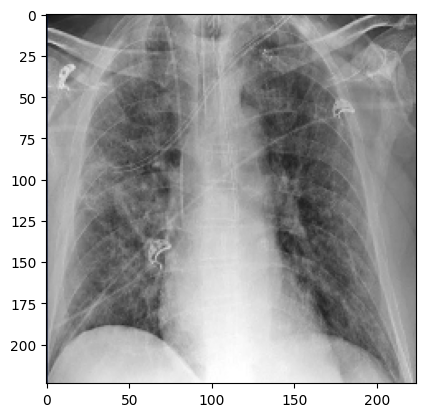

In [43]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import urllib.request

# Cargando imagen a predecir:
# https://radiologyassistant.nl/chest/covid-19-ct-findings-in-25-patients
URL_image_rx_test = 'https://radiologyassistant.nl/assets/x.jpg'
# http://www.meddean.luc.edu/lumen/meded/medicine/pulmonar/cxr/atlas/cxratlas_f.htm
URL_image_rx_test = 'http://www.meddean.luc.edu/lumen/meded/medicine/pulmonar/cxr/atlas/images/71bl.jpg'

with urllib.request.urlopen(URL_image_rx_test) as url:
   with open('temp.jpg', 'wb') as f:
       f.write(url.read())
image_test = 'temp.jpg'

# load an image in PIL format
image_to_predict = image.load_img(image_test, target_size=(img_width, img_height))
print('Image type:',type(image_to_predict))
print('Image size:',image_to_predict.size)
plt.imshow(image_to_predict)
plt.show()

In [44]:
# Procesando la imagen
test_image = image.img_to_array(image_to_predict) # Imagen como NumPy array
test_image = np.expand_dims(test_image, axis = 0) # Reshaping de (w,h,c) --> (1,w,h,c)
test_image = test_image.astype('float32')         # Valores de [0-255] --> [0.0-255.0]
test_image /= 255                                 # Valores en [0.0-1.0]

# Prediction
output = loaded_model.predict(test_image)[0][0]
print(output)

1/1 [==============================] - 0s 129ms/step
0.9996108


In [45]:
# Resultados
prediction = 1 if (output >= THRESHOLD) else 0

CLASSES = ['Normal', 'Covid19+']

ClassPred = CLASSES[prediction]
ClassProb = output

print("Pedicción:", ClassPred)
print("Prob: {:.2%}".format(ClassProb))

Pedicción: Covid19+
Prob: 99.96%
